In [5]:
!pip install -q sentence-transformers scikit-learn


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 101.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 42.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 60.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 12.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 188.7/188.7 MB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 84.7 MB/s eta 0:00:00


In [6]:
import pandas as pd
import numpy as np
from sentence_transformers import SentenceTransformer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
df = pd.read_csv("/content/cleaned_customer_support_english.csv")
df.head(5)

,cleaned_text,type,priority,queue
0,account disruption dear customer support teamn...,Incident,high,Technical Support
1,query smart home system integration features d...,Request,medium,Returns and Exchanges
2,inquiry regarding invoice details dear custome...,Request,low,Billing and Payments
3,question marketing agency software compatibili...,Problem,medium,Sales and Pre-Sales
4,feature query dear customer supportnni hope me...,Request,high,Technical Support


In [15]:
df['type'].value_counts()

,count
type,
Incident,9519
Request,6902
Problem,4984
Change,2535


In [13]:
texts=df['cleaned_text'].tolist()
labels=df['type'].tolist()

In [14]:
print("🔄 Generating embeddings...")
model = SentenceTransformer('all-mpnet-base-v2')
embeddings = model.encode(texts, show_progress_bar=True)

🔄 Generating embeddings...


Batches:   0%|          | 0/749 [00:00<?, ?it/s]

In [38]:
X = np.array(embeddings)
y = labels

X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.2, random_state=42)

In [29]:
print(" Training base model...")
clf = LogisticRegression(max_iter=5000, class_weight='balanced')
clf.fit(X_train, y_train)

 Training base model...


LogisticRegression(class_weight='balanced', max_iter=5000)

In [30]:
y_pred = clf.predict(X_test)

In [31]:
print("\n Accuracy:", accuracy_score(y_test, y_pred))
print("\n Classification Report:\n", classification_report(y_test, y_pred))


 Accuracy: 0.774900814366256

 Classification Report:
               precision    recall  f1-score   support

      Change       0.90      0.92      0.91       496
    Incident       0.79      0.66      0.72      1925
     Problem       0.50      0.67      0.57      1001
     Request       0.97      0.97      0.97      1367

    accuracy                           0.77      4789
   macro avg       0.79      0.80      0.79      4789
weighted avg       0.79      0.77      0.78      4789



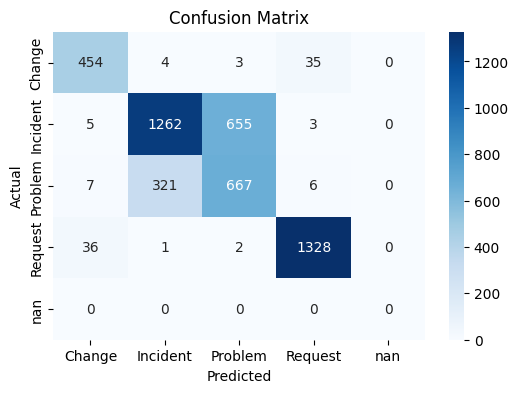

In [32]:
cm = confusion_matrix(y_test, y_pred, labels=clf.classes_)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=clf.classes_, yticklabels=clf.classes_)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()


In [33]:
from sklearn.svm import SVC
print("Training SVM...")
svm_clf = SVC(kernel='linear', class_weight='balanced')
svm_clf.fit(X_train, y_train)

Training SVM...


SVC(class_weight='balanced', kernel='linear')

In [39]:
y_pred_svm = svm_clf.predict(X_test)

In [40]:
print("\n Accuracy:", accuracy_score(y_test, y_pred_svm))
print("\n Classification Report:\n", classification_report(y_test, y_pred_svm))


 Accuracy: 0.773647943203174

 Classification Report:
               precision    recall  f1-score   support

      Change       0.92      0.92      0.92       496
    Incident       0.80      0.64      0.71      1925
     Problem       0.50      0.69      0.58      1001
     Request       0.97      0.97      0.97      1367

    accuracy                           0.77      4789
   macro avg       0.80      0.80      0.79      4789
weighted avg       0.80      0.77      0.78      4789



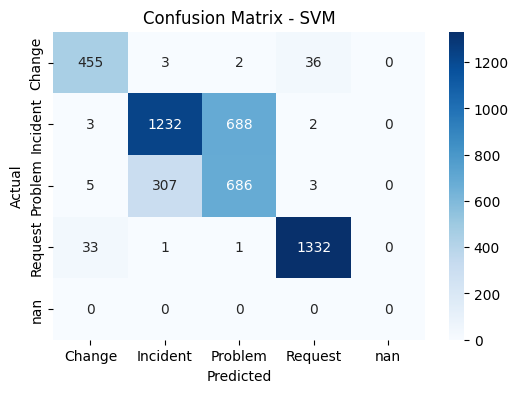

In [41]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_svm, labels=svm_clf.classes_)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=svm_clf.classes_, yticklabels=svm_clf.classes_)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - SVM")
plt.show()

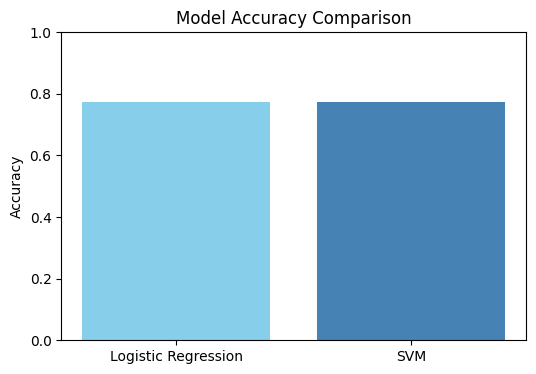

In [44]:
models = ['Logistic Regression', 'SVM']
accuracies = [0.7749, 0.7736]

plt.figure(figsize=(6,4))
plt.bar(models, accuracies, color=['skyblue','steelblue'])
plt.ylabel("Accuracy")
plt.ylim(0,1)
plt.title("Model Accuracy Comparison")
plt.show()